In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv('C:/Users/bvrsc/OneDrive/Documents/data.csv')

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

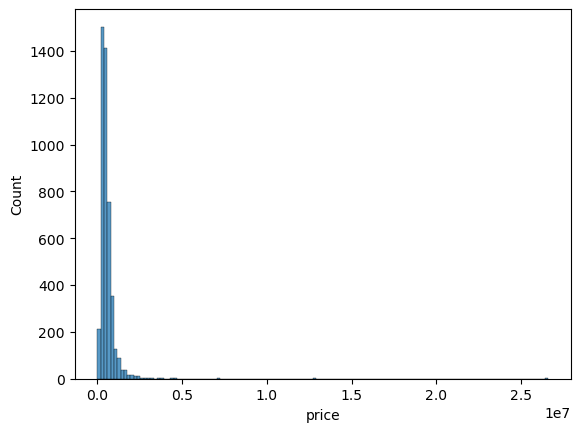

In [7]:
sns.histplot(df['price'])

plt.show()

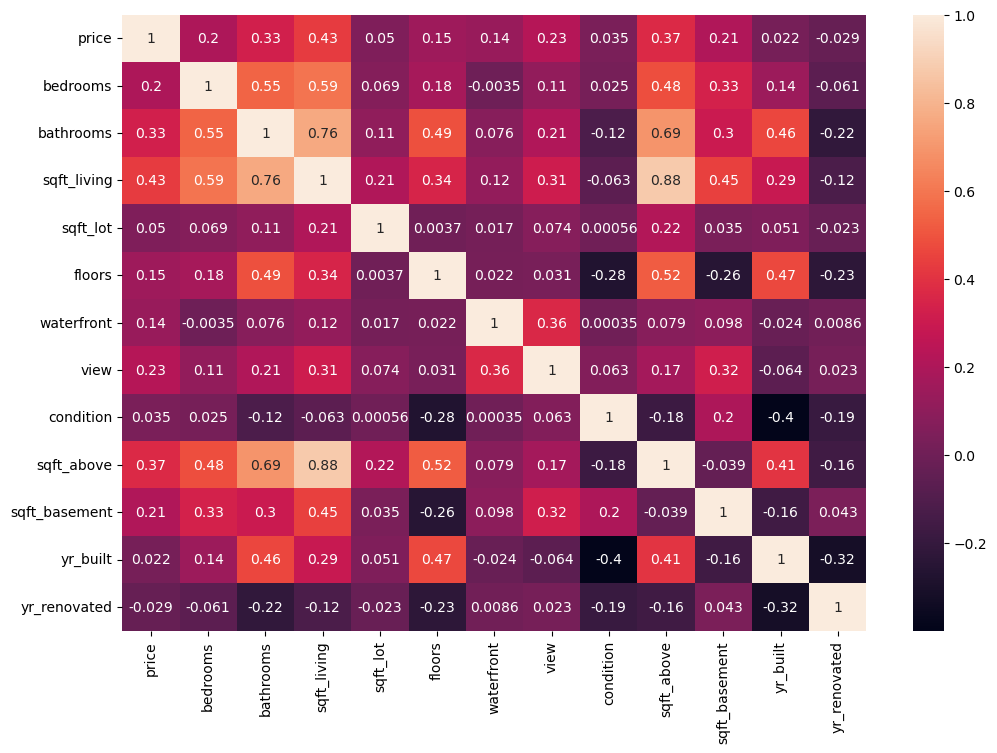

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [9]:
df = df.drop(['date', 'street', 'city', 'statezip', 'country'], axis=1)

In [10]:
X = df.drop('price', axis=1)

y = df['price']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 210908.17325012683


In [14]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression RMSE:", lr_rmse)

Linear Regression RMSE: 993439.3625461739


In [15]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [16]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 995605.4400475095


In [17]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [18]:
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting RMSE: 989821.9112104322


In [19]:
models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ]
})

print(models)

               Model           RMSE
0  Linear Regression  993439.362546
1      Random Forest  995605.440048
2  Gradient Boosting  989821.911210


In [20]:
sample = [[3, 2, 1500, 4000, 1, 0, 0, 3, 1500, 0, 1995, 0]]

prediction = rf.predict(sample)

print("Predicted House Price:", prediction)

Predicted House Price: [382903.93333333]


C:\Users\bvrsc\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [21]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

['house_price_model.pkl']